In [ ]:
# Gradient Ascent - GRAPE - 3 qubits

import numpy as np
import os
import json
import re
import ast
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D
from datetime import datetime
from qiskit.quantum_info import Pauli
from numba import njit

np.set_printoptions(linewidth=200, precision=4, suppress=True)

pauli_x = Pauli('X')
pauli_y = Pauli('Y')
pauli_z = Pauli('Z')
identity = Pauli('I')

X = pauli_x.to_matrix()
Y = pauli_y.to_matrix()
Z = pauli_z.to_matrix()
I = identity.to_matrix()

def kron3(A, B, C):
    return np.kron(A, np.kron(B, C))

Ix1 = kron3(X/2, I, I)
Iy1 = kron3(Y/2, I, I)
Iz1 = kron3(Z/2, I, I)

Ix2 = kron3(I, X/2, I)
Iy2 = kron3(I, Y/2, I)
Iz2 = kron3(I, Z/2, I)

Ix3 = kron3(I, I, X/2)
Iy3 = kron3(I, I, Y/2)
Iz3 = kron3(I, I, Z/2)

U_cnot = np.array([[1,0,0,0],
                   [0,1,0,0],
                   [0,0,0,1],
                   [0,0,1,0]], dtype=np.complex128)

U_perm = np.array([[1,0,0,0],
                   [0,0,0,1],
                   [0,1,0,0],
                   [0,0,1,0]], dtype=np.complex128)

U_cz = np.array([[1,0,0,0],
                [0,1,0,0],
                [0,0,1,0],
                [0,0,0,-1]], dtype=np.complex128)

U_toffoli = np.array([[1,0,0,0,0,0,0,0],
                      [0,1,0,0,0,0,0,0],
                      [0,0,1,0,0,0,0,0],
                      [0,0,0,1,0,0,0,0],
                      [0,0,0,0,1,0,0,0],
                      [0,0,0,0,0,1,0,0],
                      [0,0,0,0,0,0,0,1],
                      [0,0,0,0,0,0,1,0]], dtype=np.complex128)

U_fredkin = np.array([[1,0,0,0,0,0,0,0],
                      [0,1,0,0,0,0,0,0],
                      [0,0,1,0,0,0,0,0],
                      [0,0,0,1,0,0,0,0],
                      [0,0,0,0,1,0,0,0],
                      [0,0,0,0,0,0,1,0],
                      [0,0,0,0,0,1,0,0],
                      [0,0,0,0,0,0,0,1]], dtype=np.complex128)

# constants
n = 3
d = 2**n
w1_max = 6447

chem1 = 29.75
chem2 = -1383.8
chem3 = 999.50
J12 = -128.0
J13 = 68.2
J23 = 48.8

H_x = 2*np.pi*w1_max*(Ix1+Ix2+Ix3)
H_y = 2*np.pi*w1_max*(Iy1+Iy2+Iy3)

ZZI = kron3(Z/2,Z/2,I)
ZIZ = kron3(Z/2,I,Z/2)
IZZ = kron3(I,Z/2,Z/2)

H_J = 2*np.pi* (chem1*Iz1 + chem2*Iz2 + chem3*Iz3) + 2*np.pi* (J12*ZZI + J13*ZIZ + J23*IZZ)

@njit
def fast_expm(H, dt):
    w, v = np.linalg.eigh(H)
    exp_diag = np.exp(-1j * w * dt)
    return v @ np.diag(exp_diag) @ v.conj().T

@njit
def p_calc_3q(Rx, Ry, U_target, T, N, H_x, H_y, H_J):
    d = 8
    P_list = np.zeros((N, d, d), dtype=np.complex128)
    P = U_target.copy()
    dt = T / N

    for k in range(N-1, -1, -1):
        H = H_J.copy()
        H += Rx[k] * H_x
        H += Ry[k] * H_y

        Uk = fast_expm(H, dt)
        P = Uk.conj().T @ P
        P_list[k] = P

    return P_list
  
@njit
def x_calc_3q(Rx, Ry, T, N, H_x, H_y, H_J):
    d = 8
    X_list = np.zeros((N, d, d), dtype=np.complex128)
    U = np.eye(d, dtype=np.complex128)
    dt = T / N

    for k in range(N):
        H = H_J.copy()
        H += Rx[k] * H_x
        H += Ry[k] * H_y

        Uk = fast_expm(H, dt)
        U = Uk @ U
        X_list[k] = U

    return X_list, U

def fidelity_grape(U, U_target):
    phi = np.trace(U_target.conj().T @ U)
    return np.abs(phi)**2/d**2

@njit
def clip_vector(Rx, Ry, max_norm=1.0):
    norm = np.sqrt(Rx**2 + Ry**2)
    scale = np.maximum(1.0, norm / max_norm)
    return Rx / scale, Ry / scale

@njit
def gaussiansquare_envelope(N, rise_frac=0.15):
    rise_len = int(N * rise_frac)
    flat_len = N - 2 * rise_len

    sigma = rise_len / 3.0
    t = np.arange(rise_len)

    rise = np.exp(-0.5 * ((t - rise_len)**2) / sigma**2)
    fall = rise[::-1]

    flat = np.ones(flat_len)

    env = np.concatenate((rise, flat, fall))

    return env / np.max(env)

@njit
def grape_grad_3q(Rx, Ry, U_target, T, N, H_x, H_y, H_J):
    d = 8
    dt = T / N

    X_list, U_final = x_calc_3q(Rx, Ry, T, N, H_x, H_y, H_J)
    P_list = p_calc_3q(Rx, Ry, U_target, T, N, H_x, H_y, H_J)

    phi = np.trace(U_target.conj().T @ U_final)
    F0 = np.abs(phi)**2 / d**2

    grad_Rx = np.zeros(N)
    grad_Ry = np.zeros(N)

    for k in range(N):
        Xk = X_list[k]
        Pk = P_list[k]

        dX_Rx = -1j * dt * (H_x @ Xk)
        dX_Ry = -1j * dt * (H_y @ Xk)

        grad_Rx[k] = 2 * np.real(
            np.trace(Pk.conj().T @ dX_Rx) * np.conj(phi)
        )

        grad_Ry[k] = 2 * np.real(
            np.trace(Pk.conj().T @ dX_Ry) * np.conj(phi)
        )

    return F0, grad_Rx, grad_Ry, U_final

@njit
def grape_grad_3q_envelope(
    Rx, Ry, U_target, T, N,
    H_x, H_y, H_J, env
):
    dt = T / N

    Rx_env = env * Rx
    Ry_env = env * Ry

    X_list, U_final = x_calc_3q(
        Rx_env, Ry_env, T, N, H_x, H_y, H_J
    )
    P_list = p_calc_3q(
        Rx_env, Ry_env, U_target, T, N, H_x, H_y, H_J
    )

    phi = np.trace(U_target.conj().T @ U_final)
    F0 = np.abs(phi)**2 / d**2

    grad_Rx = np.zeros(N)
    grad_Ry = np.zeros(N)

    for k in range(N):
        Xk = X_list[k]
        Pk = P_list[k]

        dX_Rx = -1j * dt * (H_x @ Xk)
        dX_Ry = -1j * dt * (H_y @ Xk)

        grad_Rx[k] = 2*np.real(
            np.trace(Pk.conj().T @ dX_Rx) * np.conj(phi)
        )

        grad_Ry[k] = 2*np.real(
            np.trace(Pk.conj().T @ dX_Ry) * np.conj(phi)
        )

        grad_Rx[k] *= env[k]
        grad_Ry[k] *= env[k]

    return F0, grad_Rx, grad_Ry, U_final

def pulse_optimize_grape_lbfgs_3q_env(
    U_target, T, N,
    startParameters=None,
    max_iter=1000,
    lambda_smooth=1e-3,
    delta_RF=0.05,
    gaus_rise_frac=0.15
):

    """
    Optimize GRAPE pulses using L-BFGS-B with:
        - Smoothness penalty
        - Robustness to RF amplitude fluctuations
        - Gaussian Square envelope
        
    Args:
        U_target: target unitary matrix of result state to achieve
        J: J-coupling constant
        T: total pulse duration
        N: number of segmentations of pulse duration
        H_x, H_y: fixed Hamiltionians
        startParameters: initial state if not optimizing pulse from scratch
        max_iter: maximum permitted iterations for scipy.minimize function
        lambda_smooth: smoothing factor
        delta_RF: RF field perturbation factor (percentage)
        gaus_rise_frac: gaussian square rising section fraction of whole pulse duration
    """
    
    if startParameters is not None:
        Rx, Ry = startParameters
    else:
        Rx = np.full(N, 0.2)
        Ry = np.full(N, 0.2)

    params0 = np.concatenate([Rx, Ry])

    bounds = [(-1, 1)] * len(params0)

    env = gaussiansquare_envelope(N, gaus_rise_frac)

    def cost_function(params):
        Rx = params[:N]
        Ry = params[N:]

        Rx, Ry = clip_vector(Rx, Ry)

        perturbations = [1-delta_RF, 1, 1+delta_RF]

        F_total = 0
        grad_Rx_total = np.zeros(N)
        grad_Ry_total = np.zeros(N)

        for scale in perturbations:
            Rx_scaled = Rx * scale
            Ry_scaled = Ry * scale

            F, gRx, gRy, _ = grape_grad_3q_envelope(
                Rx_scaled, Ry_scaled,
                U_target, T, N,
                H_x, H_y, H_J, env
            )

            F_total += F / len(perturbations)

            grad_Rx_total += gRx * scale / len(perturbations)
            grad_Ry_total += gRy * scale / len(perturbations)

        # Smoothness penalty
        Rx_phys = env * Rx
        Ry_phys = env * Ry

        dRx = np.diff(Rx_phys, prepend=Rx_phys[0])
        dRy = np.diff(Ry_phys, prepend=Ry_phys[0])

        smooth_cost = lambda_smooth * (
            np.sum(dRx**2) + np.sum(dRy**2)
        )

        grad_smooth_Rx = 2*lambda_smooth*dRx
        grad_smooth_Ry = 2*lambda_smooth*dRy

        cost = 1 - F_total + smooth_cost

        grad = np.concatenate([
            -grad_Rx_total + grad_smooth_Rx,
            -grad_Ry_total + grad_smooth_Ry
        ])

        return cost, grad

    res = minimize(
        cost_function,
        params0,
        method='L-BFGS-B',
        jac=True,
        bounds=bounds,
        options={'maxiter': max_iter}
    )

    Rx_opt = res.x[:N]
    Ry_opt = res.x[N:]

    Rx_opt, Ry_opt = clip_vector(Rx_opt, Ry_opt)

    F_final, _, _, U_final = grape_grad_3q_envelope(
        Rx_opt, Ry_opt,
        U_target, T, N,
        H_x, H_y, H_J, env
    )

    return Rx_opt, Ry_opt, F_final, U_final

def export_to_json_GRAPE_1channel(
    filename,
    title,
    fidelity,
    totalpulsewidth,
    slices,
    Rx,
    Ry,
    owner="Unknown"
):
    """
    Export 3-qubit 1-channel GRAPE pulse to SpinQLab JSON format.
    Saves file inside ./pulses/

    Args:
        filename: output filename without extension
        title: pulse title
        fidelity: achieved fidelity
        totalpulsewidth: total pulse width in seconds
        slices: number of pulse slices
        Rx, Ry: optimized control vectors
        owner: metadata field
    """

    # Create output folder
    folder = "pulses"
    os.makedirs(folder, exist_ok=True)

    filepath = os.path.join(folder, filename + ".json")

    Rx = np.asarray(Rx).flatten()
    Ry = np.asarray(Ry).flatten()

    if len(Rx) != slices or len(Ry) != slices:
        raise ValueError("Rx and Ry must have length == slices")

    # slice width in microseconds
    dt_us = totalpulsewidth / slices * 1e6

    channel_pulses = []

    for k in range(slices):
        amplitude = 100 * np.sqrt(Rx[k]**2 + Ry[k]**2)
        phase = np.degrees(np.arctan2(Ry[k], Rx[k])) % 360

        channel_pulses.append({
            "detuning": 0.0,
            "phase": float(phase),
            "amplitude": float(amplitude),
            "width": float(dt_us)
        })

    data = {
        "description": {
            "TITLE": title,
            "OWNER": owner,
            "DATE": datetime.now().strftime("%d-%m-%Y"),
            "FIDELITY": float(fidelity),
            "TOTALPULSEWIDTH": float(totalpulsewidth),
            "SLICES": int(slices),
        },
        "parameters": {
            "offset": [{
                "channel1_pulsefre_offset": 0,
                "channel1_framefre_offset": 0
            }]
        },
        "pulse": {
            "channel1_pulse": channel_pulses
        }
    }

    with open(filepath, "w") as f:
        json.dump(data, f, indent=4)

    print(f"Pulse file saved to {filepath}")

def plot_pulse_from_json_1c(json_file):
    """
    Plot 1-channel GRAPE pulse from exported JSON file.
    Bar color represents phase.
    """
    
    with open(json_file, "r") as f:
        data = json.load(f)

    ch1 = data["pulse"]["channel1_pulse"]

    amp = np.array([p["amplitude"] for p in ch1])
    phase = np.array([p["phase"] for p in ch1])
    width = np.array([p["width"] for p in ch1])

    # Start time of each pulse slice
    t = np.concatenate(([0], np.cumsum(width[:-1])))

    # Phase colormap
    norm = mcolors.Normalize(vmin=0, vmax=360)
    cmap = plt.cm.hsv
    colors = cmap(norm(phase))

    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

    ax.bar(
        t,
        amp,
        width=width,
        color=colors,
        align="edge",
        edgecolor="none"
    )

    ax.set_ylabel("Amplitude (%)")
    ax.set_xlabel("Time (μs)")
    ax.set_title("3-Qubit GRAPE Pulse (1 Channel)")
    ax.set_xlim([0, None])
    ax.set_ylim([0, 100])

    # Phase colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Phase (deg)")

    plt.show()


In [2]:

dt = 5e-6
T = 20e-3
N = int(T/dt)

alpha = 0.01
start_params = (np.full(N,alpha), np.full(N,alpha))

Rx, Ry, F_final, U_final = pulse_optimize_grape_lbfgs_3q_env(
    U_fredkin, T, N,
    startParameters=start_params,
    max_iter=3000,
    lambda_smooth=0,
    delta_RF=0.05,
    gaus_rise_frac=0.1
)

print("Final fidelity:", F_final)
print(U_final)

export_to_json_GRAPE_1channel("FREDKIN_1st_test","First fredkin gate optimization attempt",F_final,T,N,Rx,Ry,"andreroque")

Final fidelity: 0.7416019241910679
[[ 0.8313+0.4906j -0.0232-0.0837j  0.0779+0.1963j -0.0581-0.0164j  0.0067+0.0624j  0.0205+0.002j  -0.0031+0.0099j  0.0864-0.0239j]
 [ 0.083 -0.0245j  0.9346+0.2582j  0.0301-0.0719j -0.0345-0.0723j -0.0167+0.0501j -0.1105-0.0471j  0.0504-0.1267j -0.0583-0.0276j]
 [-0.1966+0.0776j  0.0304-0.0716j  0.9314+0.2263j  0.0289+0.0845j -0.063 +0.1238j -0.0083-0.0224j -0.0329+0.0377j -0.0153+0.0042j]
 [ 0.0581+0.0158j  0.0722-0.0351j -0.0839+0.0305j  0.8194+0.5307j -0.0743+0.0355j  0.0683-0.0995j  0.0185-0.0634j -0.0157+0.0542j]
 [-0.0622+0.0072j -0.0164+0.0505j -0.0638+0.1235j  0.0346+0.0746j  0.7173+0.565j  -0.0704+0.2678j  0.1614+0.0266j -0.0769-0.1551j]
 [-0.0208-0.003j   0.0473-0.1103j  0.0219-0.0085j  0.0684-0.0991j -0.2675-0.0684j  0.3501+0.3622j  0.6988+0.0694j  0.0396-0.3812j]
 [ 0.0043-0.01j    0.1259+0.0513j -0.0368-0.0344j  0.0189-0.0641j -0.0268+0.1625j  0.6978+0.071j  -0.4855+0.4224j -0.1683-0.1133j]
 [-0.0235-0.0867j  0.0586+0.0276j  0.0149-0.0038

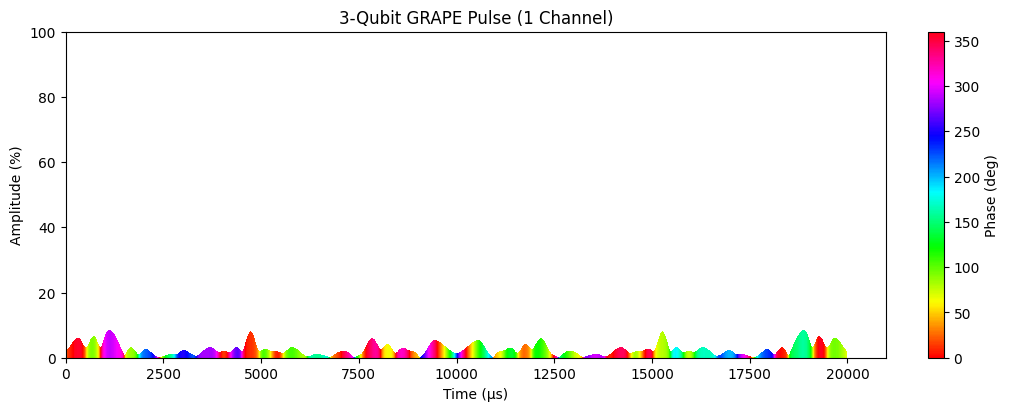

In [3]:
plot_pulse_from_json_1c("pulses/FREDKIN_1st_test.json")

Final fidelity: 0.6371499795478159
Pulse file saved to pulses\FREDKIN_time10.0.json


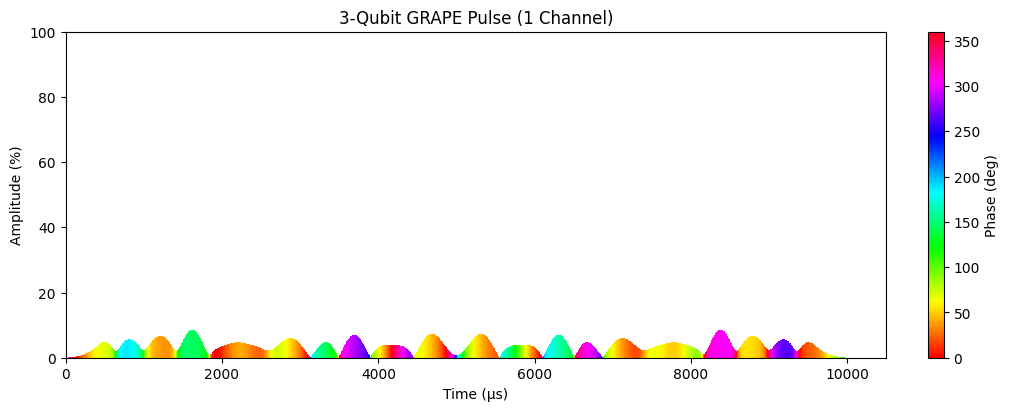

Final fidelity: 0.5258692120534725
Pulse file saved to pulses\FREDKIN_time15.0.json


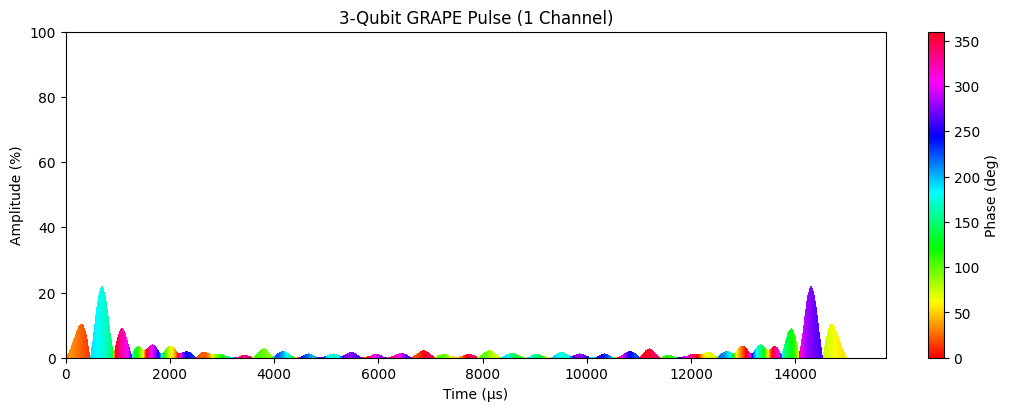

Final fidelity: 0.7780380556163086
Pulse file saved to pulses\FREDKIN_time20.0.json


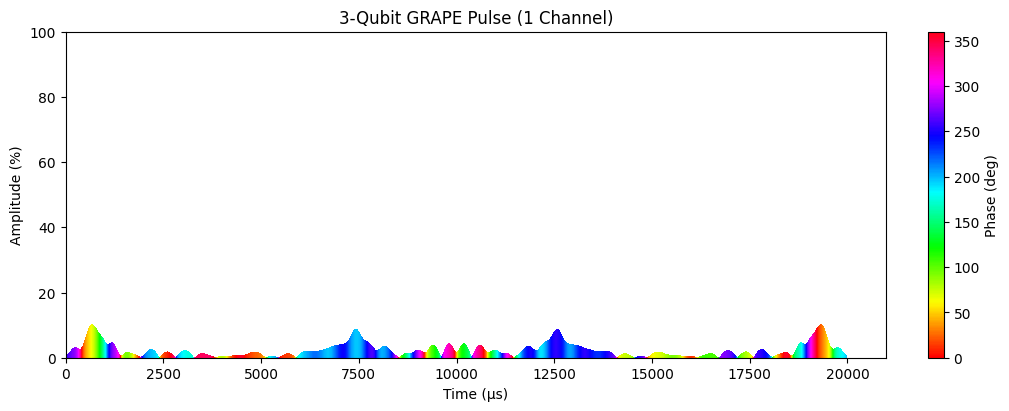

Final fidelity: 0.8699587773743588
Pulse file saved to pulses\FREDKIN_time25.0.json


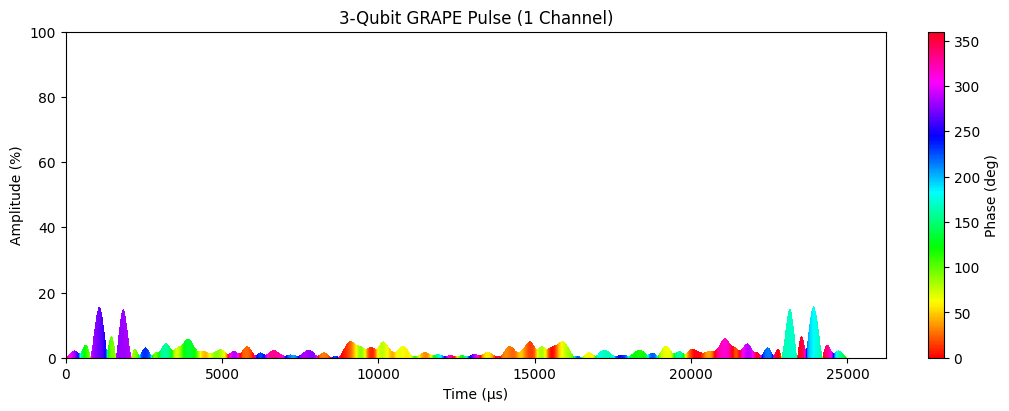

Final fidelity: 0.2892040215760781
Pulse file saved to pulses\FREDKIN_time30.0.json


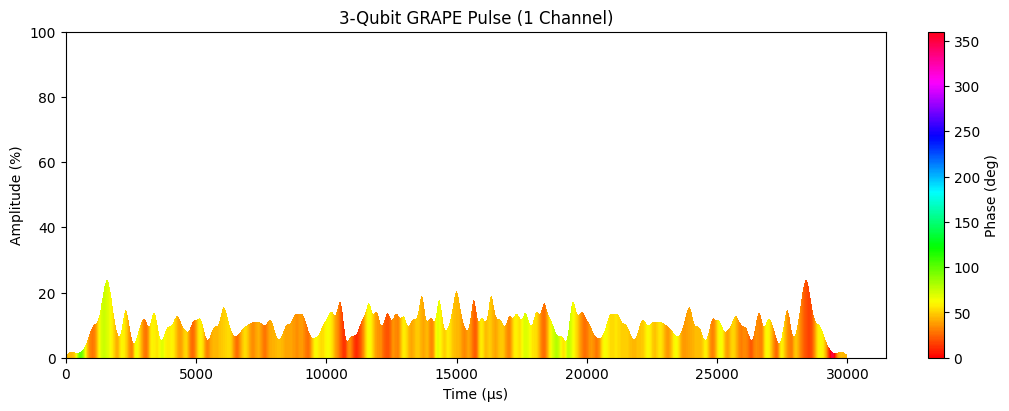

Final fidelity: 0.9923238819619014
Pulse file saved to pulses\FREDKIN_time35.0.json


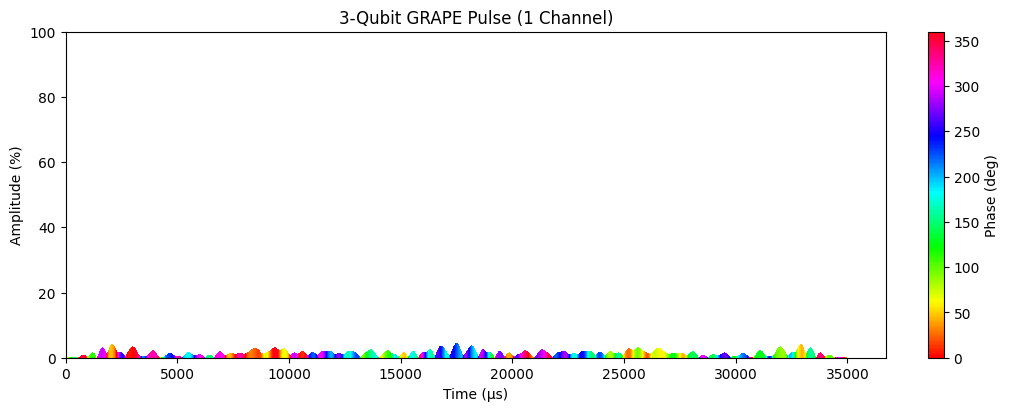

Final fidelity: 0.9953710974437309
Pulse file saved to pulses\FREDKIN_time40.0.json


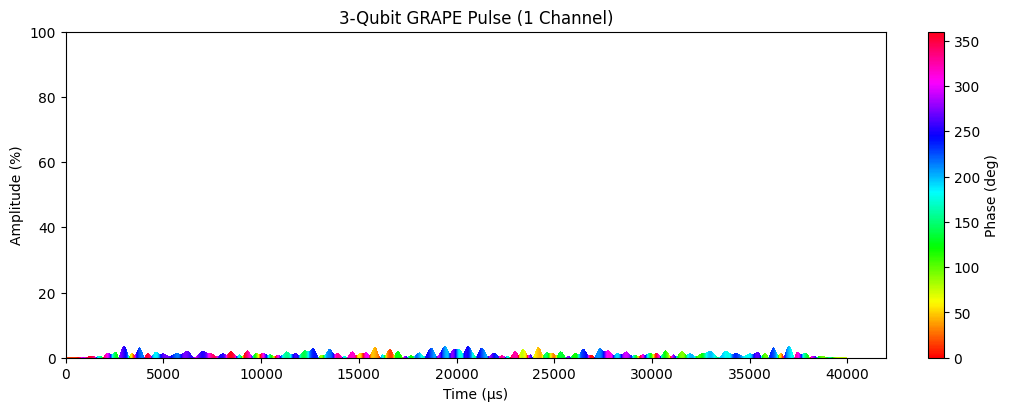

In [4]:
Ts = [10e-3,15e-3,20e-3,25e-3,30e-3,35e-3,40e-3]
dt = 5e-6

for T in Ts:
    N = int(T/dt)
    alpha = 0.001
    start_params = (np.full(N,alpha), np.full(N,alpha))
    
    Rx, Ry, F_final, U_final = pulse_optimize_grape_lbfgs_3q_env(
    U_fredkin, T, N,
    startParameters=start_params,
    max_iter=3000,
    lambda_smooth=5e-3,
    delta_RF=0.05,
    gaus_rise_frac=0.1
    )

    print("Final fidelity:", F_final)

    export_to_json_GRAPE_1channel("FREDKIN_time"+str(T*1e3),"Fredkin gate pulse duration study",F_final,T,N,Rx,Ry,"andreroque")
    plot_pulse_from_json_1c("pulses/FREDKIN_time"+str(T*1e3)+".json")

Final fidelity: 0.5397925752337621
Pulse file saved to pulses\FREDKIN_time3.0.json


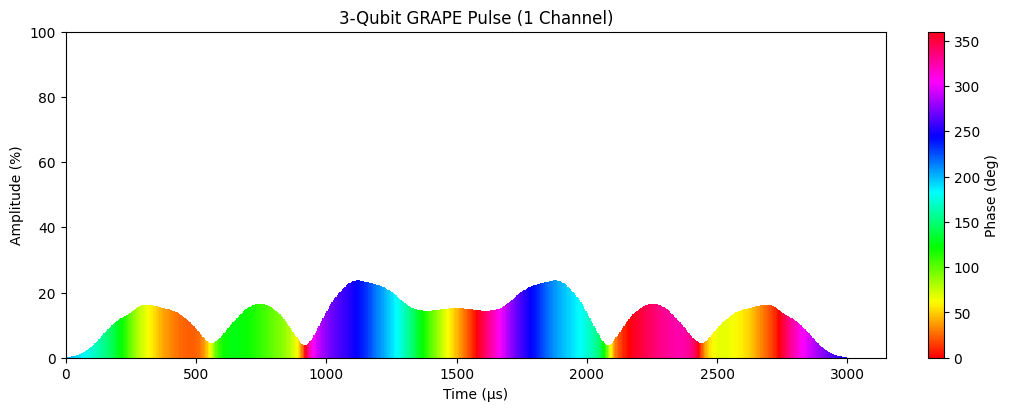

Final fidelity: 0.5517798831318624
Pulse file saved to pulses\FREDKIN_time4.0.json


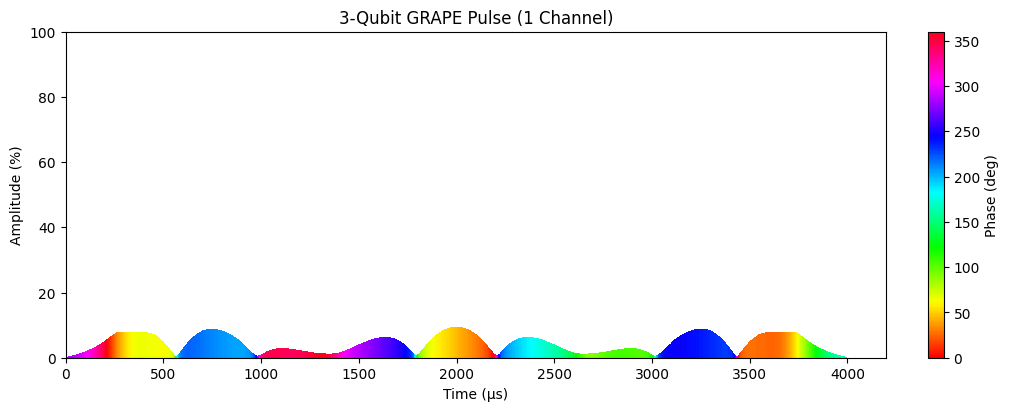

Final fidelity: 0.547974074312639
Pulse file saved to pulses\FREDKIN_time5.0.json


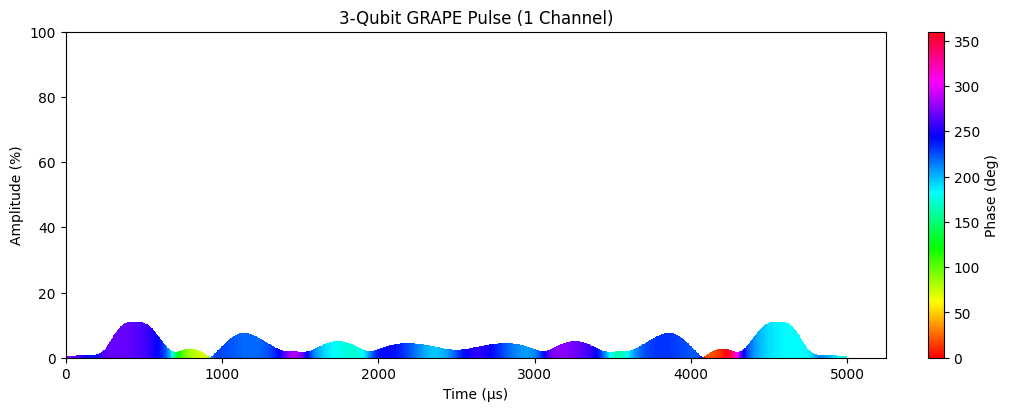

Final fidelity: 0.5550389094860863
Pulse file saved to pulses\FREDKIN_time6.0.json


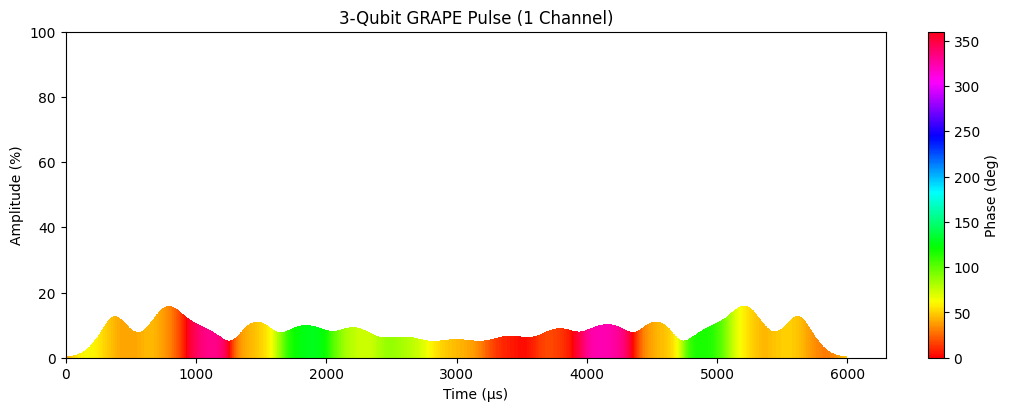

Final fidelity: 0.576092864227375
Pulse file saved to pulses\FREDKIN_time7.0.json


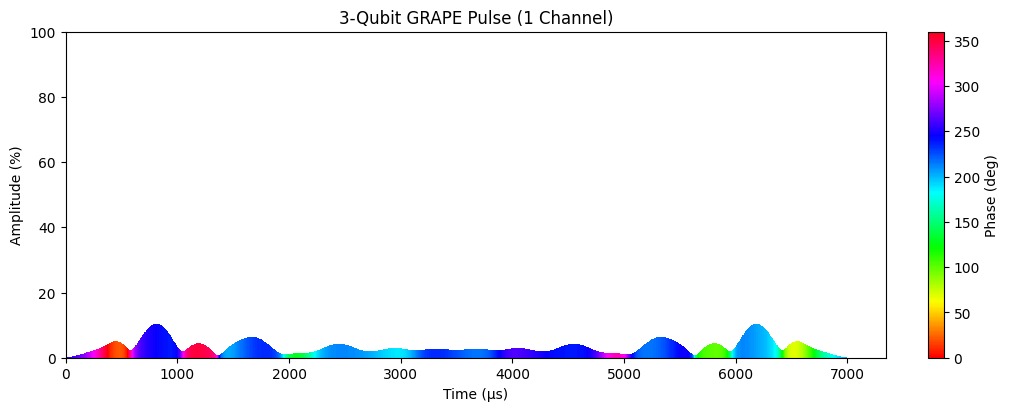

Final fidelity: 0.5963524169884672
Pulse file saved to pulses\FREDKIN_time8.0.json


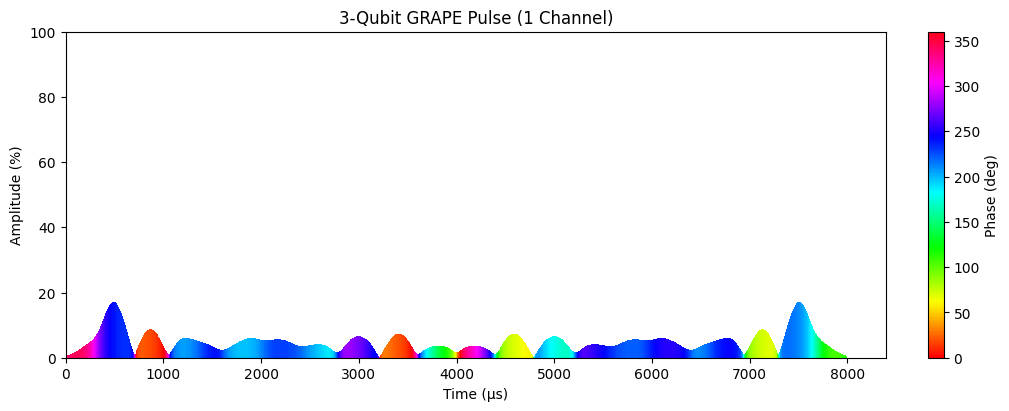

Final fidelity: 0.5653750281558308
Pulse file saved to pulses\FREDKIN_time9.0.json


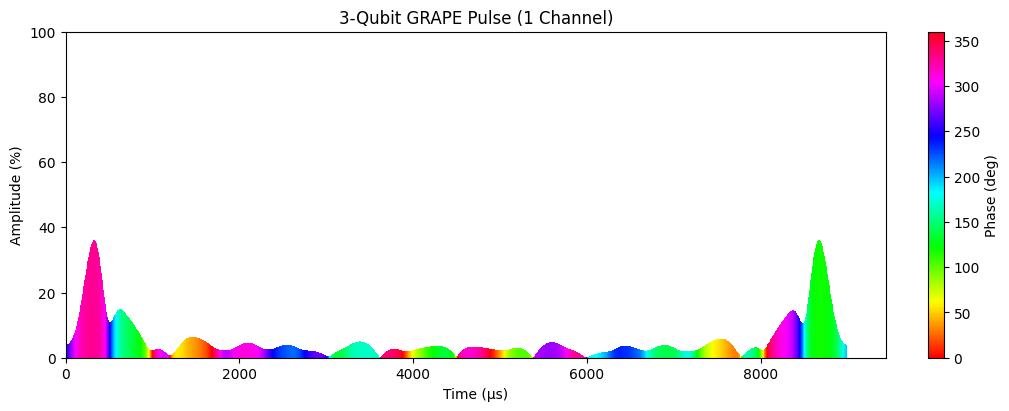

In [6]:
Ts = [3e-3,4e-3,5e-3,6e-3,7e-3,8e-3,9e-3]
dt = 5e-6

for T in Ts:
    N = int(T/dt)
    alpha = 0.001
    start_params = (np.full(N,alpha), np.full(N,alpha))
    
    Rx, Ry, F_final, U_final = pulse_optimize_grape_lbfgs_3q_env(
    U_fredkin, T, N,
    startParameters=start_params,
    max_iter=3000,
    lambda_smooth=5e-3,
    delta_RF=0.05,
    gaus_rise_frac=0.1
    )

    print("Final fidelity:", F_final)

    export_to_json_GRAPE_1channel("FREDKIN_time"+str(T*1e3),"Fredkin gate pulse duration study",F_final,T,N,Rx,Ry,"andreroque")
    plot_pulse_from_json_1c("pulses/FREDKIN_time"+str(T*1e3)+".json")

Final fidelity: 0.6371499795478159
Pulse file saved to pulses\FREDKIN_time10.0.json


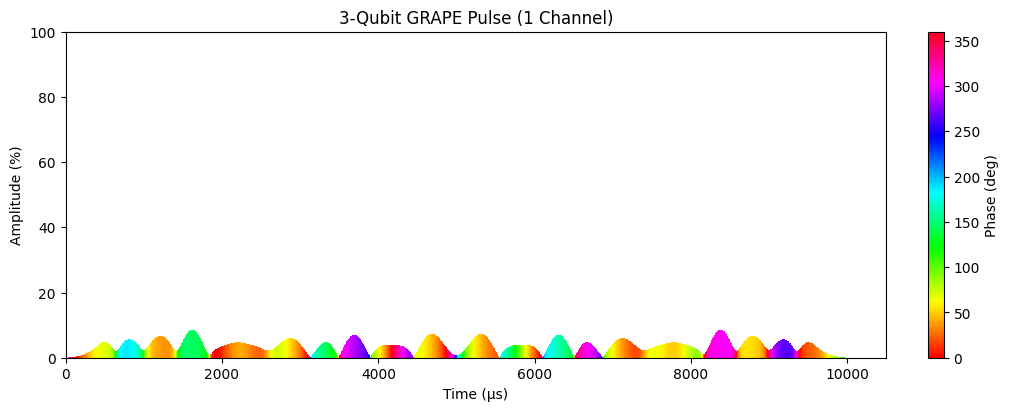

Final fidelity: 0.4942148492522643
Pulse file saved to pulses\FREDKIN_time11.0.json


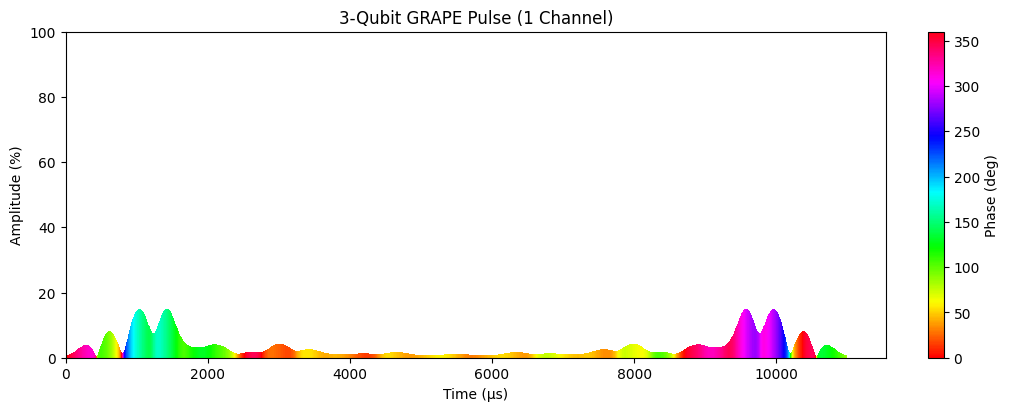

Final fidelity: 0.39507105416790617
Pulse file saved to pulses\FREDKIN_time12.0.json


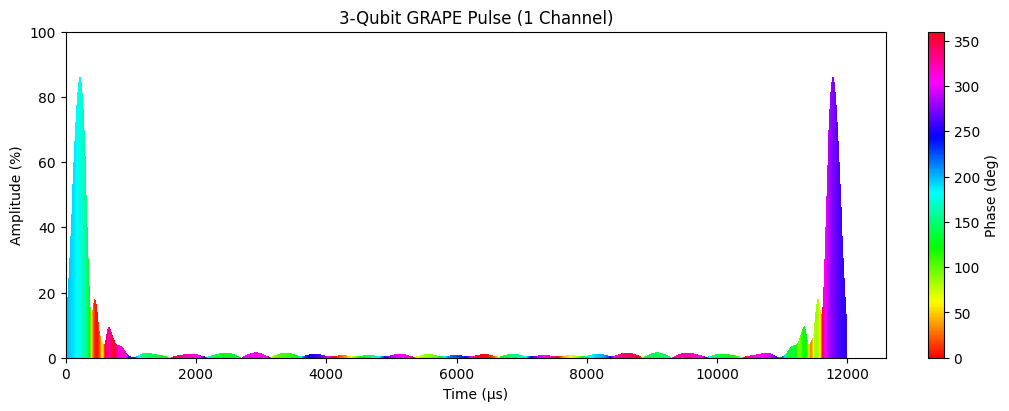

Final fidelity: 0.5483002561757003
Pulse file saved to pulses\FREDKIN_time13.0.json


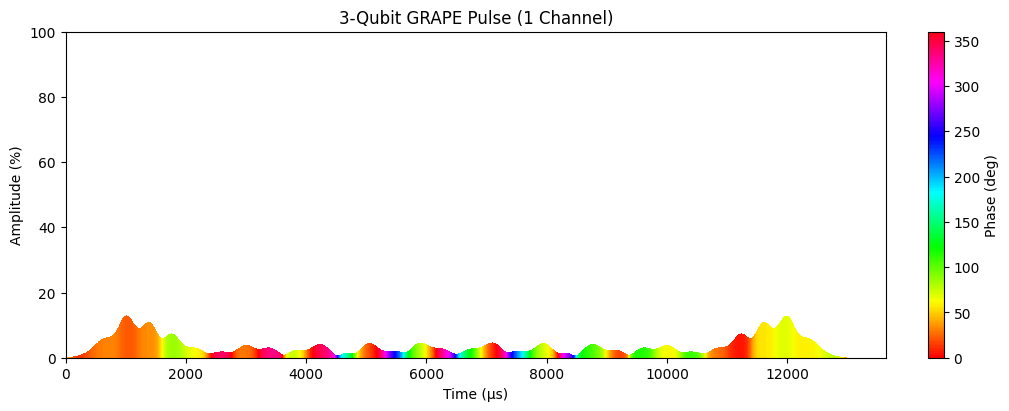

Final fidelity: 0.47842918502995324
Pulse file saved to pulses\FREDKIN_time14.0.json


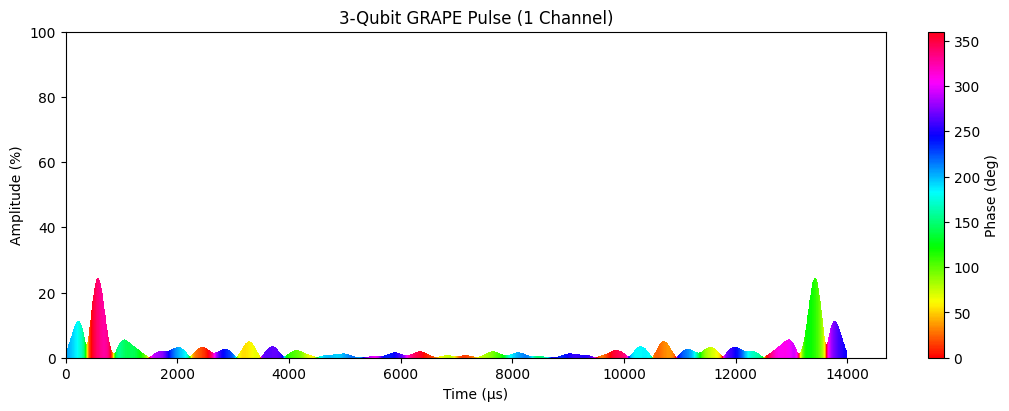

Final fidelity: 0.5258692120534725
Pulse file saved to pulses\FREDKIN_time15.0.json


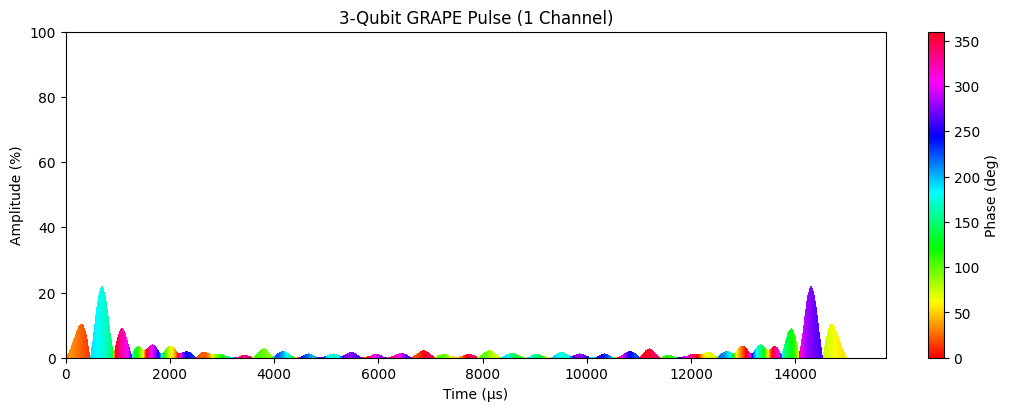

Final fidelity: 0.6383323853878426
Pulse file saved to pulses\FREDKIN_time16.0.json


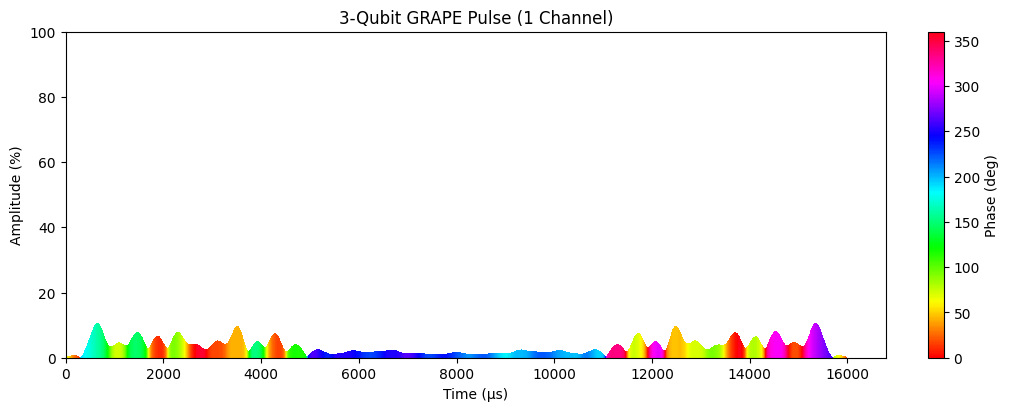

In [7]:
Ts = [10e-3,11e-3,12e-3,13e-3,14e-3,15e-3,16e-3]
dt = 5e-6

for T in Ts:
    N = int(T/dt)
    alpha = 0.001
    start_params = (np.full(N,alpha), np.full(N,alpha))
    
    Rx, Ry, F_final, U_final = pulse_optimize_grape_lbfgs_3q_env(
    U_fredkin, T, N,
    startParameters=start_params,
    max_iter=3000,
    lambda_smooth=5e-3,
    delta_RF=0.05,
    gaus_rise_frac=0.1
    )

    print("Final fidelity:", F_final)

    export_to_json_GRAPE_1channel("FREDKIN_time"+str(T*1e3),"Fredkin gate pulse duration study",F_final,T,N,Rx,Ry,"andreroque")
    plot_pulse_from_json_1c("pulses/FREDKIN_time"+str(T*1e3)+".json")

toffoli because why not

Final fidelity: 0.6590576020007156
Pulse file saved to pulses\TOFFOLI_time10.0.json


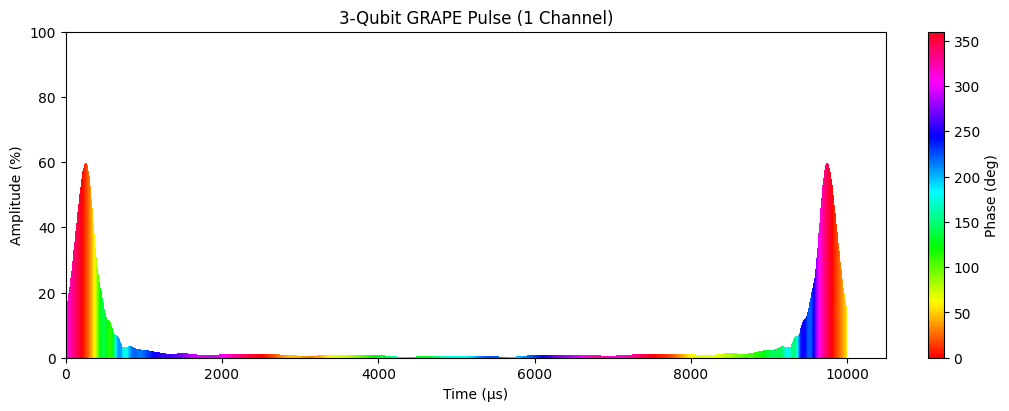

Final fidelity: 0.8909888685791678
Pulse file saved to pulses\TOFFOLI_time15.0.json


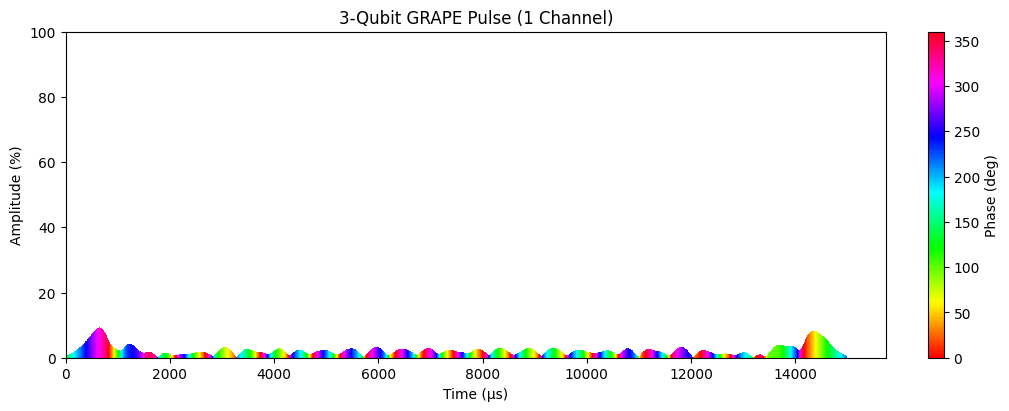

Final fidelity: 0.9884224857776703
Pulse file saved to pulses\TOFFOLI_time20.0.json


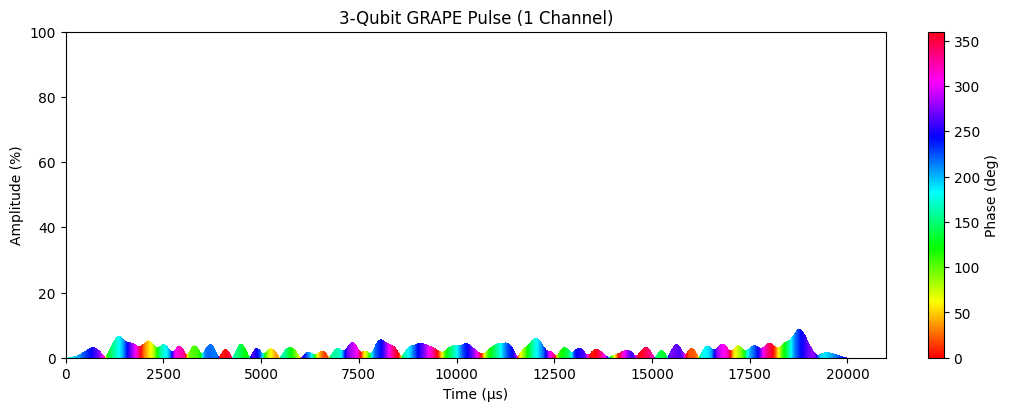

Final fidelity: 0.9738778788147733
Pulse file saved to pulses\TOFFOLI_time25.0.json


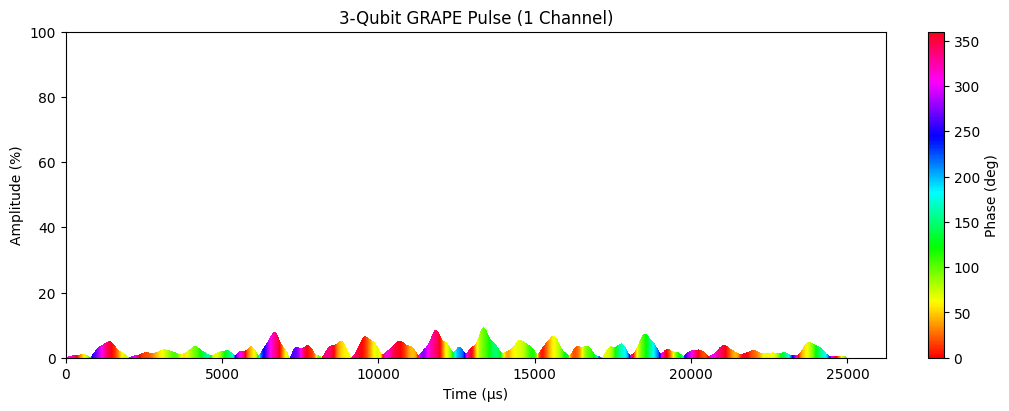

Final fidelity: 0.9990529906300394
Pulse file saved to pulses\TOFFOLI_time30.0.json


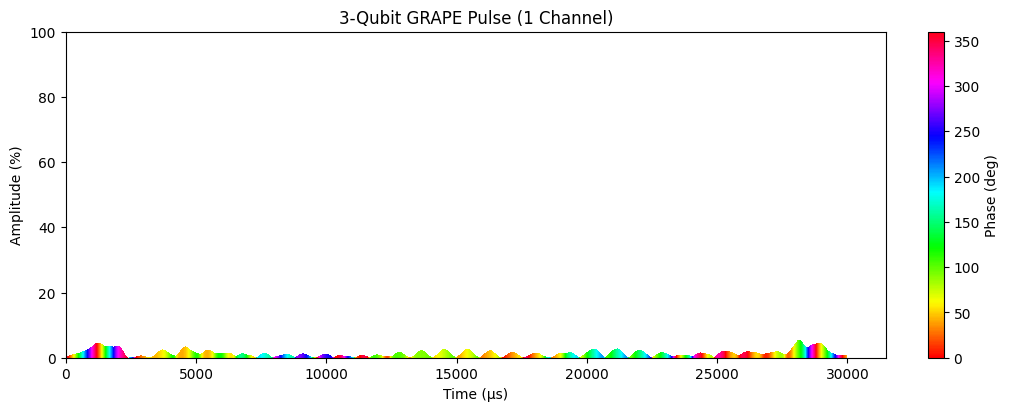

Final fidelity: 0.9982599858707742
Pulse file saved to pulses\TOFFOLI_time35.0.json


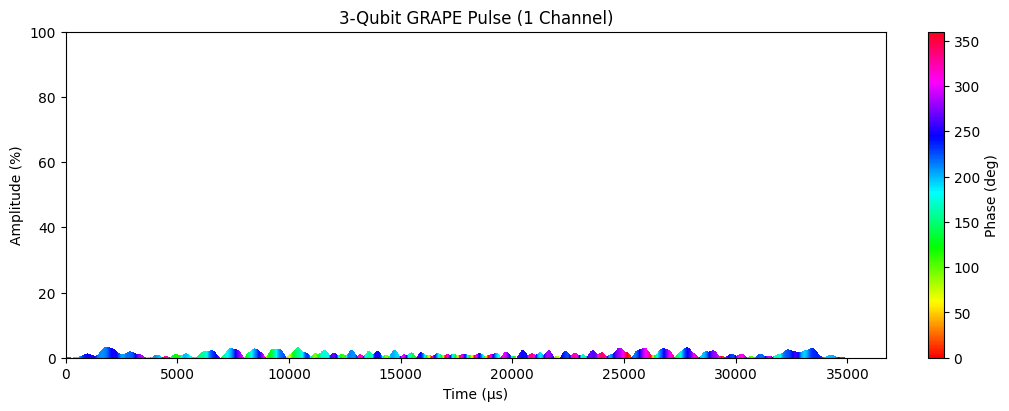

Final fidelity: 0.05645162853554364
Pulse file saved to pulses\TOFFOLI_time40.0.json


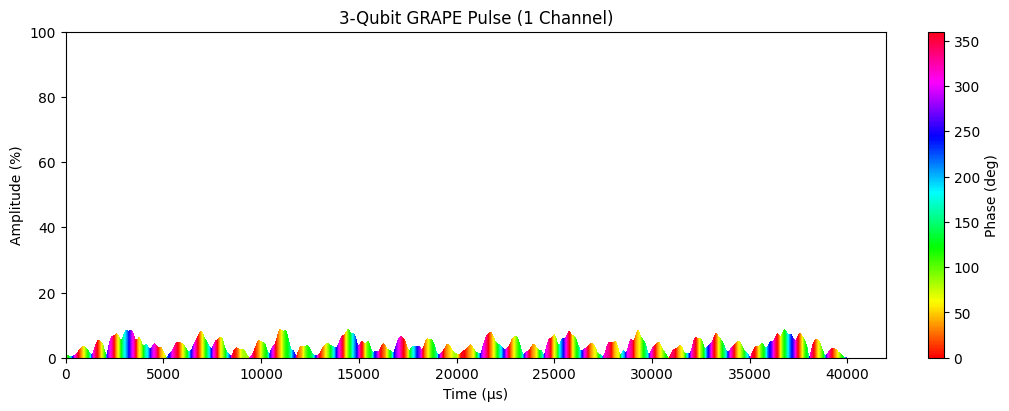

In [5]:
Ts = [10e-3,15e-3,20e-3,25e-3,30e-3,35e-3,40e-3]
dt = 5e-6

for T in Ts:
    N = int(T/dt)
    alpha = 0.001
    start_params = (np.full(N,alpha), np.full(N,alpha))
    
    Rx, Ry, F_final, U_final = pulse_optimize_grape_lbfgs_3q_env(
    U_toffoli, T, N,
    startParameters=start_params,
    max_iter=3000,
    lambda_smooth=5e-3,
    delta_RF=0.05,
    gaus_rise_frac=0.1
    )

    print("Final fidelity:", F_final)

    export_to_json_GRAPE_1channel("TOFFOLI_time"+str(T*1e3),"Toffoli gate pulse duration study",F_final,T,N,Rx,Ry,"andreroque")
    plot_pulse_from_json_1c("pulses/TOFFOLI_time"+str(T*1e3)+".json")

fredkin seems to have a difficult minimum to find, compared to toffoli

#### Quantum 20/4/26

Think about introducing detuning. GRAPE pulses from spinq dont have it --> natural stepup...